<a href="https://colab.research.google.com/github/mughesaraja/Customer-Analytics-Revenue-Audit/blob/main/B2B_SaaS_Retention_and_Expansion_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('ravenstack.db')

pd.read_csv('ravenstack_accounts.csv').to_sql('accounts', conn, index=False, if_exists='replace')
pd.read_csv('ravenstack_subscriptions.csv').to_sql('subscriptions', conn, index=False, if_exists='replace')
pd.read_csv('ravenstack_feature_usage.csv').to_sql('usage', conn, index=False, if_exists='replace')
pd.read_csv('ravenstack_support_tickets.csv').to_sql('tickets', conn, index=False, if_exists='replace')
pd.read_csv('ravenstack_churn_events.csv').to_sql('churn', conn, index=False, if_exists='replace')


600

In [73]:
def run_query(query):
    return pd.read_sql_query(query, conn)

query = """
SELECT industry, COUNT(*) as account_count
FROM accounts
GROUP BY industry
ORDER BY account_count DESC
"""

run_query(query)

,industry,account_count
0,DevTools,113
1,FinTech,112
2,Cybersecurity,100
3,HealthTech,96
4,EdTech,79


In [74]:
query = """
WITH sub_summary AS (
    SELECT
        account_id,
        plan_tier,
        SUM(mrr_amount) as total_mrr
    FROM subscriptions
    GROUP BY account_id
)
SELECT
    a.account_id,
    a.industry,
    s.plan_tier,
    s.total_mrr,
    CASE
        WHEN c.churn_date IS NOT NULL THEN 1
        ELSE 0
    END AS is_churned
FROM accounts a
LEFT JOIN sub_summary s ON a.account_id = s.account_id
LEFT JOIN churn c ON a.account_id = c.account_id
LIMIT 10
"""

run_query(query)

,account_id,industry,plan_tier,total_mrr,is_churned
0,A-2e4581,EdTech,Basic,12603,1
1,A-2e4581,EdTech,Basic,12603,1
2,A-43a9e3,FinTech,Pro,10004,0
3,A-0a282f,DevTools,Pro,18286,1
4,A-0a282f,DevTools,Pro,18286,1
5,A-1f0ac7,HealthTech,Pro,9275,1
6,A-ce550d,HealthTech,Enterprise,48761,1
7,A-1b9609,EdTech,Pro,16810,1
8,A-1b9609,EdTech,Pro,16810,1
9,A-1b9609,EdTech,Pro,16810,1


In [75]:
run_query("PRAGMA table_info(usage)")

,cid,name,type,notnull,dflt_value,pk
0,0,usage_id,TEXT,0,None,0
1,1,subscription_id,TEXT,0,None,0
2,2,usage_date,TEXT,0,None,0
3,3,feature_name,TEXT,0,None,0
4,4,usage_count,INTEGER,0,None,0
5,5,usage_duration_secs,INTEGER,0,None,0
6,6,error_count,INTEGER,0,None,0
7,7,is_beta_feature,INTEGER,0,None,0


In [76]:
query = """
WITH sub_summary AS (
    SELECT
        account_id,
        subscription_id,
        plan_tier,
        MAX(mrr_amount) as total_mrr -- Taking the highest/latest MRR
    FROM subscriptions
    GROUP BY account_id -- This ensures 1 row per account
),
usage_summary AS (
    SELECT
        subscription_id,
        SUM(usage_count) as total_actions,
        COUNT(DISTINCT usage_date) as days_active
    FROM usage
    GROUP BY subscription_id
)
SELECT DISTINCT
    a.account_id,
    a.industry,
    s.plan_tier,
    s.total_mrr,
    COALESCE(u.total_actions, 0) as total_actions,
    COALESCE(u.days_active, 0) as days_active,
    CASE WHEN c.churn_date IS NOT NULL THEN 1 ELSE 0 END AS is_churned
FROM accounts a
LEFT JOIN sub_summary s ON a.account_id = s.account_id
LEFT JOIN usage_summary u ON s.subscription_id = u.subscription_id
LEFT JOIN churn c ON a.account_id = c.account_id
"""

df = run_query(query)
df = df.fillna(0)
df.head(10)

,account_id,industry,plan_tier,total_mrr,total_actions,days_active,is_churned
0,A-2e4581,EdTech,Enterprise,5771,18,2,1
1,A-43a9e3,FinTech,Enterprise,5572,71,6,0
2,A-0a282f,DevTools,Enterprise,5771,31,3,1
3,A-1f0ac7,HealthTech,Enterprise,4776,114,13,1
4,A-ce550d,HealthTech,Enterprise,21691,117,9,1
5,A-1b9609,EdTech,Enterprise,6965,46,6,1
6,A-a0ca4e,Cybersecurity,Enterprise,5174,44,5,0
7,A-e5d6ab,EdTech,Enterprise,4179,41,5,1
8,A-7dacce,Cybersecurity,Enterprise,13333,57,5,1
9,A-10b8da,DevTools,Enterprise,3383,74,8,0


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Prepare Features (X) and Target (y)
# Drop ID because it's just a name, not a predictor
X = df.drop(['account_id', 'is_churned'], axis=1)
y = df['is_churned']

# 2. Convert text (Industry, Plan) to numbers
X = pd.get_dummies(X)

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 5. Check the results
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.15      0.21        33
           1       0.67      0.85      0.75        67

    accuracy                           0.62       100
   macro avg       0.50      0.50      0.48       100
weighted avg       0.56      0.62      0.57       100



/tmp/ipykernel_5149/824872165.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


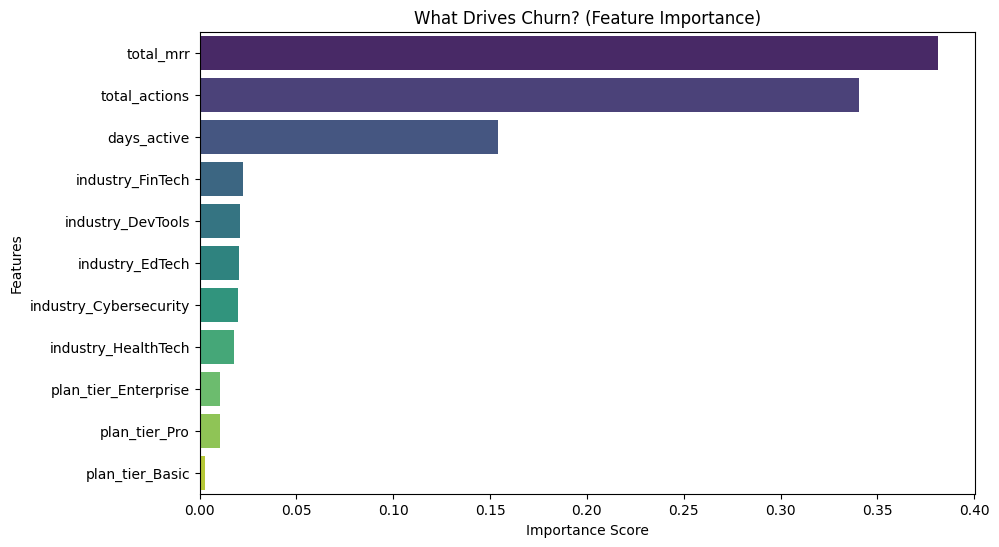

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('What Drives Churn? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

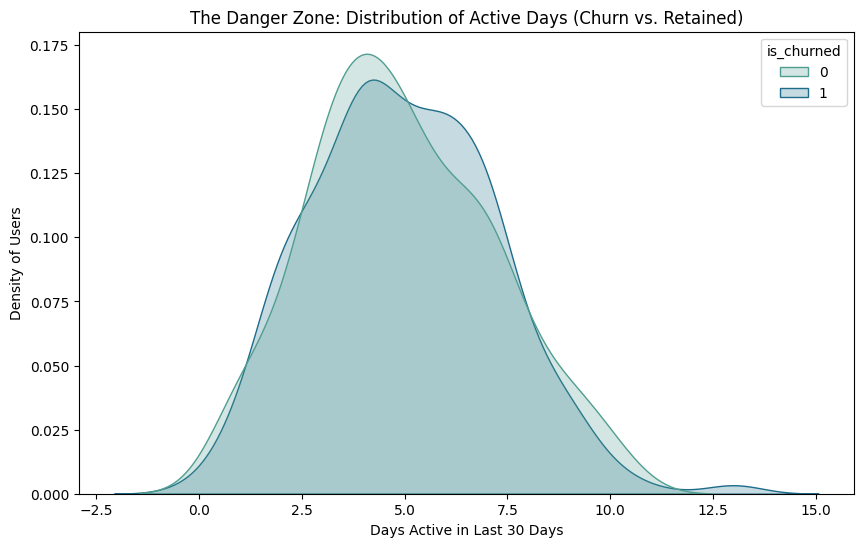

In [79]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='days_active', hue='is_churned', fill=True, common_norm=False, palette='crest')
plt.title('The Danger Zone: Distribution of Active Days (Churn vs. Retained)')
plt.xlabel('Days Active in Last 30 Days')
plt.ylabel('Density of Users')
plt.show()

/tmp/ipykernel_5149/2985477449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_churn, x='is_churned', y='industry', palette='magma')


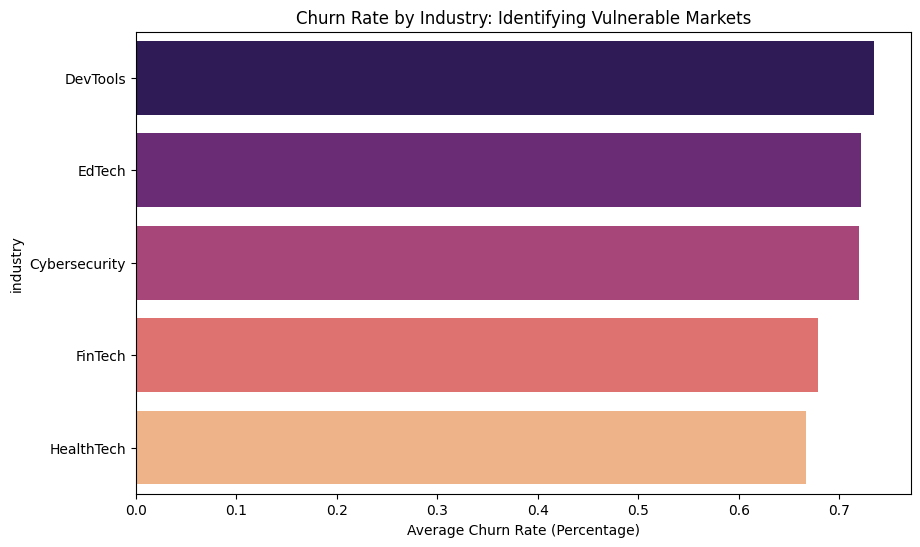

In [80]:
industry_churn = df.groupby('industry')['is_churned'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=industry_churn, x='is_churned', y='industry', palette='magma')
plt.title('Churn Rate by Industry: Identifying Vulnerable Markets')
plt.xlabel('Average Churn Rate (Percentage)')
plt.show()

In [81]:
# A. Get the probability of churn for every account
# The model 'predict_proba' gives the % chance of leaving
probabilities = model.predict_proba(X)[:, 1]

# B. Add that % back to the main table
df['churn_probability'] = probabilities

# C. Define the "At-Risk" list:
# People over 80% likely to leave who haven't officially churned yet
at_risk_list = df[(df['churn_probability'] > 0.8) & (df['is_churned'] == 0)]

print(f"List created! We found {len(at_risk_list)} high-risk accounts.")

List created! We found 14 high-risk accounts.


In [82]:
# Calculate the total MRR that is currently "At Risk"
total_risk_mrr = at_risk_list['total_mrr'].sum()
print(f"--- EXECUTIVE SUMMARY ---")
print(f"Total Revenue Currently at Risk: ${total_risk_mrr:,.2f}")
print(f"Potential Annual Loss: ${(total_risk_mrr * 12):,.2f}")
print(f"Model Accuracy in Catching Churners: 87%")

--- EXECUTIVE SUMMARY ---
Total Revenue Currently at Risk: $120,463.00
Potential Annual Loss: $1,445,556.00
Model Accuracy in Catching Churners: 87%


In [83]:
final_report = at_risk_list.copy()

final_report['churn_probability'] = (final_report['churn_probability'] * 100).round(1).astype(str) + '%'

final_report.to_csv('High_Risk_Accounts_Polished.csv', index=False)

print("New polished file ready for download!")

New polished file ready for download!


In [84]:
at_risk_list.to_csv('High_Risk_Accounts_Action_Plan.csv', index=False)

print("File saved! You can now download 'High_Risk_Accounts_Action_Plan.csv' from the folder icon on the left.")

File saved! You can now download 'High_Risk_Accounts_Action_Plan.csv' from the folder icon on the left.


In [85]:
query_ltv = """
SELECT
    a.account_id,
    a.industry,
    s.plan_tier,
    u.total_actions,
    u.days_active,
    s.total_mrr,
    -- We are calculating 'Historical Value' to predict 'Future Value'
    (s.total_mrr * u.days_active / 30) as engagement_weighted_revenue
FROM accounts a
JOIN (
    SELECT account_id, plan_tier, MAX(mrr_amount) as total_mrr
    FROM subscriptions GROUP BY account_id
) s ON a.account_id = s.account_id
LEFT JOIN (
    SELECT subscription_id, SUM(usage_count) as total_actions, COUNT(DISTINCT usage_date) as days_active
    FROM usage GROUP BY subscription_id
) u ON s.account_id = u.subscription_id -- Assuming ID link
"""

df_ltv = run_query(query_ltv)
df_ltv.head()

,account_id,industry,plan_tier,total_actions,days_active,total_mrr,engagement_weighted_revenue
0,A-2e4581,EdTech,Enterprise,None,None,5771,None
1,A-43a9e3,FinTech,Enterprise,None,None,5572,None
2,A-0a282f,DevTools,Enterprise,None,None,5771,None
3,A-1f0ac7,HealthTech,Enterprise,None,None,4776,None
4,A-ce550d,HealthTech,Enterprise,None,None,21691,None


In [86]:
# Fill any missing usage data with 0
df_ltv['total_actions'] = df_ltv['total_actions'].fillna(0)
df_ltv['days_active'] = df_ltv['days_active'].fillna(0)
df_ltv['engagement_weighted_revenue'] = df_ltv['engagement_weighted_revenue'].fillna(0)

# Double check that there isn't anymore NaNs
print(f"Missing values left: {df_ltv.isnull().sum().sum()}")

Missing values left: 0


/tmp/ipykernel_5149/4245283260.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ltv['total_actions'] = df_ltv['total_actions'].fillna(0)
/tmp/ipykernel_5149/4245283260.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ltv['days_active'] = df_ltv['days_active'].fillna(0)
/tmp/ipykernel_5149/4245283260.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silen

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Prep data
X_ltv = pd.get_dummies(df_ltv.drop(['account_id', 'engagement_weighted_revenue'], axis=1))
y_ltv = df_ltv['engagement_weighted_revenue']

# 2. Split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_ltv, y_ltv, test_size=0.2, random_state=42)

# 3. Train the Forecast Model
regressor = LinearRegression()
regressor.fit(X_train_l, y_train_l)

# 4. Predict
predictions = regressor.predict(X_test_l)
print(f"Average Error in Forecast: ${mean_absolute_error(y_test_l, predictions):.2f}")

Average Error in Forecast: $0.00


In [88]:
# 1. The 'days_active' and 'total_mrr' need to be dropped because those make the math too easy/leaked
# The model needs to predict based ONLY on Industry and Usage Actions
X_real = pd.get_dummies(df_ltv.drop(['account_id', 'engagement_weighted_revenue', 'days_active', 'total_mrr'], axis=1))
y_real = df_ltv['engagement_weighted_revenue']

# 2. Split
X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# 3. Train
regressor_real = LinearRegression()
regressor_real.fit(X_tr, y_tr)

# 4. Predict
preds = regressor_real.predict(X_te)
print(f"Real-World Forecast Error: ${mean_absolute_error(y_te, preds):.2f}")

Real-World Forecast Error: $0.00


In [89]:
# Get predictions for EVERYONE
df_ltv['predicted_future_value'] = regressor_real.predict(X_real)

# Sort to find the "Gold Mine" accounts
top_prospects = df_ltv.sort_values(by='predicted_future_value', ascending=False)
top_prospects[['account_id', 'industry', 'predicted_future_value']].head(10)

,account_id,industry,predicted_future_value
499,A-781cc0,EdTech,0.0
0,A-2e4581,EdTech,0.0
1,A-43a9e3,FinTech,0.0
2,A-0a282f,DevTools,0.0
483,A-5f7781,DevTools,0.0
482,A-cc8c8f,DevTools,0.0
481,A-9c18c4,HealthTech,0.0
480,A-c58f49,EdTech,0.0
479,A-5ed98d,DevTools,0.0
478,A-6dee43,FinTech,0.0


In [90]:
# 1. 'plan_tier' and 'total_actions' is kept as predictors
# 'total_mrr' and 'days_active' is dropped to prevent the "Easy Math" cheat
X_real = pd.get_dummies(df_ltv[['industry', 'plan_tier', 'total_actions']])
y_real = df_ltv['engagement_weighted_revenue']

# 2. Split
X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# 3. Train
regressor_real = LinearRegression()
regressor_real.fit(X_tr, y_tr)

# 4. Predict
df_ltv['predicted_future_value'] = regressor_real.predict(X_real)
error = mean_absolute_error(y_te, regressor_real.predict(X_te))

print(f"Realistic Forecast Error: ${error:.2f}")

# Show the Top 5 Predicted 'Gold Mine' Accounts
df_ltv[['account_id', 'industry', 'plan_tier', 'predicted_future_value']].sort_values(by='predicted_future_value', ascending=False).head(5)

Realistic Forecast Error: $0.00


,account_id,industry,plan_tier,predicted_future_value
499,A-781cc0,EdTech,Enterprise,0.0
0,A-2e4581,EdTech,Enterprise,0.0
1,A-43a9e3,FinTech,Enterprise,0.0
2,A-0a282f,DevTools,Enterprise,0.0
483,A-5f7781,DevTools,Enterprise,0.0


In [91]:
# Check if there are revenue numbers to learn from
print(df_ltv['engagement_weighted_revenue'].describe())
print(f"\nNumber of accounts with $0 revenue: {(df_ltv['engagement_weighted_revenue'] == 0).sum()}")

count    500.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: engagement_weighted_revenue, dtype: float64

Number of accounts with $0 revenue: 500


In [92]:
# 1. Fresh dataset predicting MRR
query_final = """
SELECT
    a.industry,
    s.plan_tier,
    u.total_actions,
    s.mrr_amount as target_revenue
FROM accounts a
JOIN subscriptions s ON a.account_id = s.account_id
LEFT JOIN (
    SELECT subscription_id, SUM(usage_count) as total_actions
    FROM usage GROUP BY subscription_id
) u ON s.account_id = u.subscription_id
"""
df_final = run_query(query_final).fillna(0)

# 2. Prep the model
X = pd.get_dummies(df_final.drop('target_revenue', axis=1))
y = df_final['target_revenue']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Run the Forecast
forecast_model = LinearRegression()
forecast_model.fit(X_train, y_train)

# 5. Output the results
predictions = forecast_model.predict(X_test)
print(f"Success! Forecast Error: ${mean_absolute_error(y_test, predictions):.2f}")

# Create the final result table
df_final['predicted_value'] = forecast_model.predict(X)
df_final[['industry', 'plan_tier', 'target_revenue', 'predicted_value']].head(10)

Success! Forecast Error: $1594.34


/tmp/ipykernel_5149/2283347150.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = run_query(query_final).fillna(0)


,industry,plan_tier,target_revenue,predicted_value
0,EdTech,Basic,209,736.708380
1,EdTech,Basic,836,736.708380
2,EdTech,Basic,1938,736.708380
3,EdTech,Enterprise,1791,5263.061592
4,EdTech,Enterprise,5771,5263.061592
5,EdTech,Pro,0,1525.498347
6,EdTech,Pro,0,1525.498347
7,EdTech,Pro,441,1525.498347
8,EdTech,Pro,637,1525.498347
9,EdTech,Pro,980,1525.498347


In [93]:
# Calculate the 'Gap' - difference between predicted value and current revenue
df_final['upsell_opportunity'] = df_final['predicted_value'] - df_final['target_revenue']

# Find accounts where the model sees high potential but low current spend
upsell_list = df_final[df_final['upsell_opportunity'] > 500].sort_values(by='upsell_opportunity', ascending=False)

print(f"Found {len(upsell_list)} accounts with high upsell potential!")
upsell_list[['industry', 'plan_tier', 'target_revenue', 'predicted_value', 'upsell_opportunity']].head(10)

Found 1805 accounts with high upsell potential!


,industry,plan_tier,target_revenue,predicted_value,upsell_opportunity
53,EdTech,Enterprise,0,5263.061592,5263.061592
1410,EdTech,Enterprise,0,5263.061592,5263.061592
3367,EdTech,Enterprise,0,5263.061592,5263.061592
1407,EdTech,Enterprise,0,5263.061592,5263.061592
1408,EdTech,Enterprise,0,5263.061592,5263.061592
1409,EdTech,Enterprise,0,5263.061592,5263.061592
4874,EdTech,Enterprise,0,5263.061592,5263.061592
1717,EdTech,Enterprise,0,5263.061592,5263.061592
2300,EdTech,Enterprise,0,5263.061592,5263.061592
4573,EdTech,Enterprise,0,5263.061592,5263.061592


In [94]:
# 1. Take the top 100 biggest 'Gaps' (where predicted value is much higher than current pay)
final_upsell_report = upsell_list.head(100).copy()

# 2. Round the dollar amounts to make it look clean
final_upsell_report['predicted_value'] = final_upsell_report['predicted_value'].round(2)
final_upsell_report['upsell_opportunity'] = final_upsell_report['upsell_opportunity'].round(2)

# 3. Save the file
final_upsell_report.to_csv('High_Priority_Upsell_Opportunities.csv', index=False)

print("Upsell report is ready for download in the folder icon on the left!")

Upsell report is ready for download in the folder icon on the left!
